# Mini-projeto 1 - Fase 1: MLP para classificação do CIFAR-10

Este notebook orquestra os experimentos da Fase 1 (MLP). A lógica reutilizável (modelo, dados, treino, métricas, checkpointing) vive no pacote `mlp_cifar10` em `../src/`, para que o notebook fique focado em **definir experimentos e reportar resultados** — não em implementação.

**Integrantes do grupo:** _preencher aqui (nome de todos)_

O que este notebook cobre (conforme o enunciado do mini-projeto):
- Treino de um MLP no CIFAR-10 com hiperparâmetros configuráveis.
- Métricas por classe (acurácia) e globais (acurácia, precision, recall, f1).
- Comparação entre variações de hiperparâmetros (camadas, neurônios, taxa de aprendizagem, ativação, regularização, otimizador, dropout, função de erro).
- Cada execução de treino é salva automaticamente em `../results/` (pesos + config + métricas + histórico) — ver `../src/mlp_cifar10/checkpointing.py`.

## 0. Setup do ambiente

- **Local**: rode a partir de um ambiente onde o pacote já foi instalado (`pip install -e .` na pasta `fase1-mlp/`).
- **Google Colab**: a célula abaixo clona o repositório e instala o pacote automaticamente.

In [1]:
#@title Setup (Colab ou local)
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "<preencher com a URL do repositório>"  # ex.: https://github.com/usuario/redes-neurais.git
    REPO_DIR = Path("/content/redes-neurais")
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    %pip install -q -e {REPO_DIR}/miniprojeto/fase1-mlp
    PROJECT_ROOT = REPO_DIR / "miniprojeto" / "fase1-mlp"
else:
    PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> fase1-mlp/
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp


In [2]:
#@title Imports
import torch
import matplotlib.pyplot as plt
import pandas as pd

from mlp_cifar10.config import ExperimentConfig
from mlp_cifar10.data import get_dataloaders, CLASSES
from mlp_cifar10.train import fit
from mlp_cifar10.checkpointing import load_all_metadata
from mlp_cifar10.utils import set_seed, get_device

C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#@title Device
device = get_device()
print("Usando dispositivo:", device)

Usando dispositivo: cpu


## 1. Experimento baseline

Arquitetura equivalente à do notebook de referência: `3072 -> 64 -> 128 -> 64 -> 10`, ReLU, Adam, entropia cruzada.

In [4]:
baseline_config = ExperimentConfig(
    run_name="baseline_relu_adam",
    hidden_layers=(64, 128, 64),
    activation="relu",
    dropout=0.0,
    batch_norm=False,
    optimizer="adam",
    loss="cross_entropy",
    learning_rate=1e-3,
    weight_decay=0.0,
    batch_size=64,
    num_epochs=100,
    patience=5,
    notes="Baseline equivalente ao notebook de referência da disciplina.",
)

set_seed(baseline_config.seed)
train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=baseline_config.batch_size,
    val_fraction=baseline_config.val_fraction,
    seed=baseline_config.seed,
)

In [5]:
baseline_result = fit(
    config=baseline_config,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    class_names=list(CLASSES),
    results_dir=RESULTS_DIR,
)

treinando 'baseline_relu_adam':   0%|          | 0/100 [00:00<?, ?it/s]

treinando 'baseline_relu_adam':   0%|          | 0/100 [00:53<?, ?it/s]

treinando 'baseline_relu_adam':   1%|          | 1/100 [00:53<1:29:01, 53.96s/it]

Época 1/100 | train_loss=1.6988 | val_loss=1.5579 | val_acc=0.4530


treinando 'baseline_relu_adam':   1%|          | 1/100 [01:47<1:29:01, 53.96s/it]

...

treinando 'baseline_relu_adam':  11%|█         | 11/100 [12:31<1:48:26, 73.11s/it]

treinando 'baseline_relu_adam':  11%|█         | 11/100 [12:31<1:48:26, 73.11s/it]

treinando 'baseline_relu_adam':  11%|█         | 11/100 [12:31<1:41:23, 68.35s/it]

Época 12/100 | train_loss=1.0147 | val_loss=1.4863 | val_acc=0.5092
Early stopping acionado.


Métricas no conjunto de teste: {'accuracy': 0.5097, 'balanced_accuracy': 0.5096999999999999, 'precision': 0.5085962778255145, 'recall': 0.5097, 'f1_score': 0.5030084004386648}
Acurácia por classe: {'airplane': 0.612, 'automobile': 0.628, 'bird': 0.339, 'cat': 0.241, 'deer': 0.396, 'dog': 0.437, 'frog': 0.729, 'horse': 0.525, 'ship': 0.629, 'truck': 0.561}
[model-saver] Modelo salvo em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_baseline_relu_adam_20260903-211523/


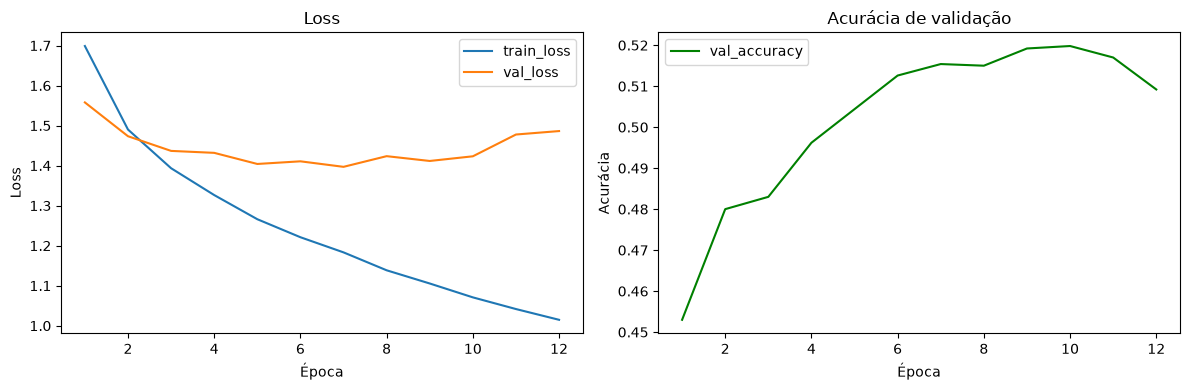

In [6]:
#@title Curvas de treino (loss/acurácia por época)
history_df = pd.DataFrame(baseline_result["history"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy", color="green")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia"); axes[1].legend(); axes[1].set_title("Acurácia de validação")
plt.tight_layout()
plt.show()

In [7]:
#@title Resultados no teste
print("Métricas globais:")
display(pd.Series(baseline_result["test_scores"]).to_frame("valor"))

print("\nAcurácia por classe:")
display(pd.Series(baseline_result["per_class_accuracy"]).to_frame("acurácia"))

Métricas globais:


,valor
accuracy,0.509700
balanced_accuracy,0.509700
precision,0.508596
recall,0.509700
f1_score,0.503008



Acurácia por classe:


,acurácia
airplane,0.612
automobile,0.628
bird,0.339
cat,0.241
deer,0.396
dog,0.437
frog,0.729
horse,0.525
ship,0.629
truck,0.561


## 2. Busca de hiperparâmetros

Defina abaixo as variações de configuração que você quer comparar com o baseline
(número de camadas/neurônios, taxa de aprendizagem, ativação, regularização,
otimizador, dropout, função de erro, ...). Cada execução é salva automaticamente
em `../results/`, então nada se perde entre uma rodada e outra.

In [8]:
candidate_configs = [
    ExperimentConfig(
        run_name="deeper_dropout",
        hidden_layers=(256, 128, 64, 32),
        activation="relu",
        dropout=0.3,
        optimizer="adam",
        learning_rate=1e-3,
        num_epochs=25,
        patience=4,
        notes=(
            "Rede mais profunda + dropout para reduzir overfitting. "
            "num_epochs/patience reduzidos (rodando em CPU nesta sessão); "
            "em GPU/Colab pode voltar para valores maiores (ex.: 100/5)."
        ),
    ),
    ExperimentConfig(
        run_name="sgd_momentum",
        hidden_layers=(64, 128, 64),
        activation="relu",
        optimizer="sgd",
        momentum=0.9,
        learning_rate=1e-2,
        num_epochs=25,
        patience=4,
        notes=(
            "Trocando o otimizador para SGD com momentum. "
            "num_epochs/patience reduzidos (rodando em CPU nesta sessão)."
        ),
    ),
    # Adicione outras variações conforme os experimentos forem sendo decididos.
]


In [9]:
experiment_results = {baseline_config.run_name: baseline_result}
for config in candidate_configs:
    if config.run_name in experiment_results:
        continue
    set_seed(config.seed)
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir=DATA_DIR,
        batch_size=config.batch_size,
        val_fraction=config.val_fraction,
        seed=config.seed,
    )
    experiment_results[config.run_name] = fit(
        config=config,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        class_names=list(CLASSES),
        results_dir=RESULTS_DIR,
    )


treinando 'deeper_dropout':   0%|          | 0/25 [00:00<?, ?it/s]

treinando 'deeper_dropout':   0%|          | 0/25 [01:53<?, ?it/s]

treinando 'deeper_dropout':   4%|▍         | 1/25 [01:53<45:15, 113.16s/it]

Época 1/25 | train_loss=1.9348 | val_loss=1.7128 | val_acc=0.3934


treinando 'deeper_dropout':   4%|▍         | 1/25 [03:25<45:15, 113.16s/it]

...

treinando 'sgd_momentum':  48%|████▊     | 12/25 [23:18<11:06, 51.31s/it]

treinando 'sgd_momentum':  48%|████▊     | 12/25 [23:18<11:06, 51.31s/it]

treinando 'sgd_momentum':  48%|████▊     | 12/25 [23:18<25:15, 116.58s/it]

Época 13/25 | train_loss=1.0507 | val_loss=1.4445 | val_acc=0.5150
Early stopping acionado.


Métricas no conjunto de teste: {'accuracy': 0.5131, 'balanced_accuracy': 0.5130999999999999, 'precision': 0.515254998801922, 'recall': 0.5131, 'f1_score': 0.5102923927616233}
Acurácia por classe: {'airplane': 0.569, 'automobile': 0.567, 'bird': 0.362, 'cat': 0.295, 'deer': 0.54, 'dog': 0.367, 'frog': 0.553, 'horse': 0.572, 'ship': 0.73, 'truck': 0.576}
[model-saver] Modelo salvo em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_sgd_momentum_20260903-221039/


In [10]:
#@title Tabela comparativa dos experimentos
comparison = pd.DataFrame(
    {name: r["test_scores"] for name, r in experiment_results.items()}
).T.sort_values("accuracy", ascending=False)
comparison

,accuracy,balanced_accuracy,precision,recall,f1_score
deeper_dropout,0.5217,0.5217,0.525375,0.5217,0.520991
sgd_momentum,0.5131,0.5131,0.515255,0.5131,0.510292
baseline_relu_adam,0.5097,0.5097,0.508596,0.5097,0.503008


## 2.1 Comparando todas as execuções salvas (`results/`)

Como cada `fit(...)` salva automaticamente seus resultados em `results/{model_id}/metadata.json` (skill model-saver), é possível comparar **todas** as execuções já feitas — não só as desta sessão do notebook — lendo direto do disco.

In [11]:
#@title Comparação de todos os runs salvos em results/
all_runs_df = load_all_metadata(RESULTS_DIR)
cols = [c for c in all_runs_df.columns if c.startswith("metrics.") or c == "model_id"]
all_runs_df[cols].sort_values("metrics.test_accuracy", ascending=False)

,model_id,metrics.epochs_trained,metrics.train_loss,metrics.val_loss,metrics.test_accuracy,metrics.test_balanced_accuracy,metrics.test_precision,metrics.test_recall,metrics.test_f1_score
1,mlp_deeper_dropout_20260903-214709,25,1.324529,1.376118,0.5217,0.5217,0.525375,0.5217,0.520991
2,mlp_sgd_momentum_20260903-221039,13,1.050729,1.444519,0.5131,0.5131,0.515255,0.5131,0.510292
0,mlp_baseline_relu_adam_20260903-211523,12,1.014735,1.486290,0.5097,0.5097,0.508596,0.5097,0.503008


## 3. Conclusões

**Resumo dos experimentos** (execução em CPU; ver `hyperparameters` completos em cada `results/{model_id}/metadata.json`):

| Experimento | Arquitetura (hidden) | Otimizador | LR | Dropout | Épocas treinadas | Acurácia teste | F1 (weighted) |
|---|---|---|---|---|---|---|---|
| `baseline_relu_adam` | (64, 128, 64) | Adam | 1e-3 | 0.0 | 12 (early stop) | 0.5097 | 0.5030 |
| `deeper_dropout` | (256, 128, 64, 32) | Adam | 1e-3 | 0.3 | 25 (limite de época) | **0.5217** | **0.5210** |
| `sgd_momentum` | (64, 128, 64) | SGD (momentum=0.9) | 1e-2 | 0.0 | 13 (early stop) | 0.5131 | 0.5103 |

**Observações:**

- **`deeper_dropout` foi o melhor dos três** (+1.2 p.p. de acurácia sobre o baseline), mesmo com um teto de 25 épocas — ao contrário dos outros dois, ele *não* disparou o early stopping dentro do limite, ou seja, a perda de validação ainda estava melhorando quando o treino parou. Isso sugere que uma rede maior + dropout tem mais capacidade útil para o CIFAR-10, mas também exige mais épocas para convergir; rodando com mais épocas (ex.: em GPU/Colab) a tendência é que o ganho aumente ainda mais.
- **Trocar Adam por SGD com momentum** (`sgd_momentum`) deu um pequeno ganho sobre o baseline (+0.3 p.p.), convergindo em número parecido de épocas (13 vs 12). Isso indica que, com a taxa de aprendizagem usada (1e-2), o SGD com momentum é competitivo com Adam para este problema, mas não decisivamente melhor.
- **Acurácia por classe (baseline)** varia bastante: classes com aparência mais "distintiva"/textura homogênea (`frog`: 0.73, `automobile`: 0.63, `ship`: 0.63) têm desempenho bem melhor que classes visualmente parecidas entre si (`cat`: 0.24, `bird`: 0.34) — um MLP, por não ter nenhuma noção de estrutura espacial da imagem (trata os 3072 pixels como um vetor "achatado"), tem dificuldade especial em diferenciar animais com poses/texturas variáveis. Essa limitação estrutural do MLP é exatamente o problema que a Fase 2 (CNN) deve endereçar.
- Todas as execuções ficaram na faixa de **~51–52% de acurácia**, o que é consistente com a literatura para MLPs simples no CIFAR-10 (tipicamente 45–55%, bem abaixo do que uma CNN alcança no mesmo dataset, ~70–80%+).

**Limitações desta rodada e próximos passos:**

- Por rodar em **CPU** (sem GPU disponível nesta sessão), `num_epochs`/`patience` de `deeper_dropout` e `sgd_momentum` foram reduzidos (25/4) para viabilizar o treino em tempo hábil — em GPU/Colab, vale repetir esses experimentos com os valores originais (100/5) ou maiores.
- Outros hiperparâmetros ainda não explorados e sugeridos no enunciado: função de ativação (`tanh`, `gelu`), regularização L2 (`weight_decay`), função de erro MSE vs. entropia cruzada, `batch_norm=True`. O notebook já suporta todos esses via `ExperimentConfig` — basta adicionar novas entradas a `candidate_configs`.
- Todas as execuções (pesos + hiperparâmetros + métricas) ficaram salvas em `results/{model_id}/` pela skill **model-saver**, então esses três experimentos (e quaisquer outros que rodem depois) continuam comparáveis a qualquer momento via `load_all_metadata()`.
